In [17]:
!pip install -q torch torchvision torchaudio
!pip install -q diffusers transformers accelerate safetensors peft datasets
!pip install -q matplotlib pillow tqdm

In [20]:
!pip uninstall -y diffusers
!pip install -e ./diffusers

Found existing installation: diffusers 0.38.0.dev0
Uninstalling diffusers-0.38.0.dev0:
  Successfully uninstalled diffusers-0.38.0.dev0
Obtaining file:///Users/anovichkovy/PycharmProjects/lab5/diffusers
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for diffusers (pyproject.toml) ... done
  Created wheel for diffusers: filename=diffusers-0.38.0.dev0-0.editable-py3-none-any.whl size=11438 sha256=69bf0889c73e5094ba39fcf6dc2795077857f5b09792136bbbc36fdce1b392ba
  Stored in directory: /private/var/folders/s4/4ydpwyl113368rq_l4hkrgw00000gn/T/pip-ephem-wheel-cache-xqxqi_by/wheels/0d/e3/43/ae42dbf1c16841eda3e9149df26e16b4f79cacd126e169fd7f
Successfully built diffusers


In [22]:
import torch
device = "mps" if torch.backends.mps.is_available() else "cpu"
print("DEVICE:", device)

DEVICE: mps


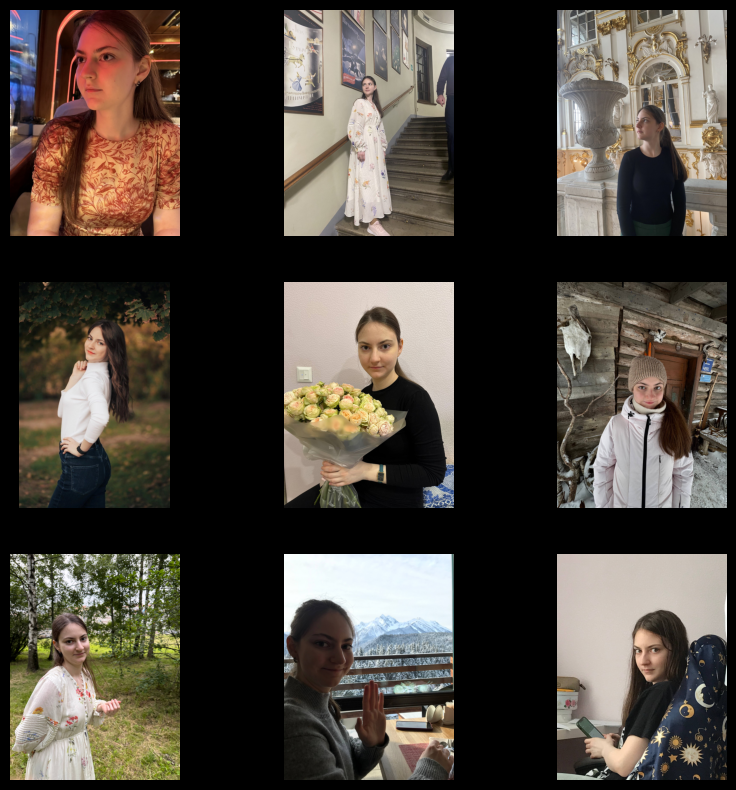

In [74]:
import os, json
from PIL import Image
import matplotlib.pyplot as plt

photos_dir = "./photos"

files = sorted([f for f in os.listdir(photos_dir) if f.lower().endswith(".jpg")])

plt.figure(figsize=(10,10))
for i in range(min(9, len(files))):
    img = Image.open(os.path.join(photos_dir, files[i])).convert("RGB")
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")
plt.show()


In [34]:
import os, json
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration
import torch

device = "mps" if torch.backends.mps.is_available() else "cpu"

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

photos_dir = "./photos"
token = "sks_person"

files = sorted([f for f in os.listdir(photos_dir) if f.lower().endswith(".jpg")])
metadata_path = os.path.join(photos_dir, "metadata.jsonl")

with open(metadata_path, "w", encoding="utf-8") as f:
    for name in files:
        img = Image.open(os.path.join(photos_dir, name)).convert("RGB")
        inputs = processor(images=img, return_tensors="pt").to(device)
        out = model.generate(**inputs, max_new_tokens=30)
        caption = processor.decode(out[0], skip_special_tokens=True)
        final_caption = f"photo of {token}, portrait, {caption}"
        f.write(json.dumps({"file_name": name, "text": final_caption}, ensure_ascii=False) + "\n")


Loading weights: 100%|██████████| 473/473 [00:00<00:00, 16947.33it/s]
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [35]:
!accelerate launch diffusers/examples/text_to_image/train_text_to_image_lora.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --train_data_dir="./photos" \
  --caption_column="text" \
  --image_column="image" \
  --output_dir="./lora_me_final" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --learning_rate=5e-5 \
  --lr_scheduler="constant" \
  --max_train_steps=450 \
  --checkpointing_steps=100 \
  --random_flip \
  --rank=16 \
  --seed=42

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `0`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
/Users/anovichkovy/PycharmProjects/lab5/.venv/lib/python3.14/site-packages/accelerate/accelerator.py:528: UserWarning: `log_with=tensorboard` was passed but no supported trackers are currently installed.
  warnings.warn(f"`log_with={log_with}` was passed but no supported trackers are currently installed.")
04/16/2026 14:52:14 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: mps

Mixed precision type: no

/Users/anovichkovy/PycharmProjects/lab5/.venv/lib/python3.14/site-packages/huggingface_hub/utils/_validators.py:205: Use

In [32]:
!pip install -q peft

In [33]:
!pip install -q --upgrade peft accelerate

In [42]:
import torch
from diffusers import StableDiffusionPipeline

device = "mps" if torch.backends.mps.is_available() else "cpu"
print("DEVICE:", device)

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float32,
    safety_checker=None,
    requires_safety_checker=False
)

pipe = pipe.to(device)
pipe.load_lora_weights("./lora_me_final")

DEVICE: mps


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 7846.56it/s]
CLIPTextModel LOAD REPORT from: /Users/anovichkovy/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 12.99it/s]
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


100%|██████████| 40/40 [00:40<00:00,  1.01s/it]


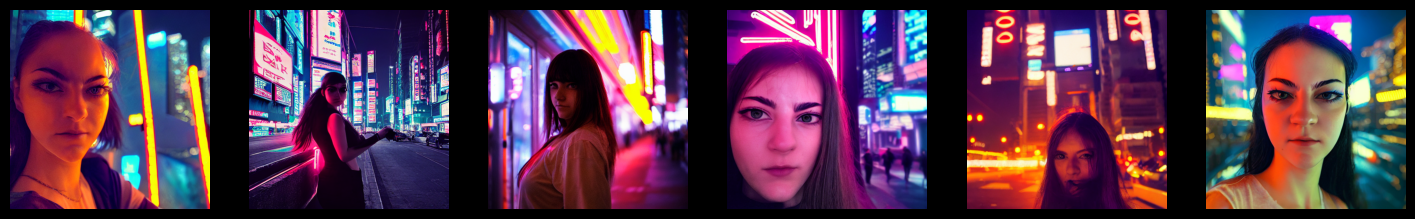

In [72]:
import torch
import matplotlib.pyplot as plt

def generate_many(prompt, k=6, steps=40, scale=7.0, seed_start=0):
    imgs = []
    for i in range(k):
        gen = torch.Generator(device=device).manual_seed(seed_start + i)
        img = pipe(prompt, num_inference_steps=steps, guidance_scale=scale, generator=gen).images[0]
        imgs.append(img)
    return imgs

prompt = "photo of sks_person, portrait, cyberpunk city at night, neon lights, cinematic lighting, realistic face, sharp focus, high quality, ultra detailed"

imgs = generate_many(prompt, k=6, steps=40, scale=7.0, seed_start=100)

plt.figure(figsize=(18,6))
for i, img in enumerate(imgs):
    plt.subplot(1,6,i+1)
    plt.imshow(img)
    plt.axis("off")
plt.show()


In [50]:
!pip install -q scikit-image

In [44]:
!pip install -q insightface opencv-python onnxruntime

In [46]:
!pip install -q transformers

In [61]:
import torch
import numpy as np
import cv2
import insightface

from transformers import CLIPProcessor, CLIPModel
import numpy as np
import cv2



device = "mps" if torch.backends.mps.is_available() else "cpu"
print("DEVICE:", device)


# ArcFace
app = insightface.app.FaceAnalysis(providers=["CPUExecutionProvider"])
app.prepare(ctx_id=0, det_size=(640, 640))

def get_embedding(pil_img):
    img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    faces = app.get(img)
    if len(faces) == 0:
        return None
    return faces[0].embedding

def cosine_sim(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))


# CLIPScore
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def clip_score(image, text):
    inputs = clip_processor(text=[text], images=image, return_tensors="pt", padding=True).to(device)
    outputs = clip_model(**inputs)
    return float(outputs.logits_per_image.item())


def sharpness_score(pil_img):
    img = np.array(pil_img.convert("RGB"))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())

DEVICE: mps
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/anovichkovy/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/anovichkovy/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/anovichkovy/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/anovichkovy/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/anovichkovy/.insightface/models/buffalo_l/w600k_r50.onnx recogn

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 32629.01it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [62]:
import os
import json
import torch
import pandas as pd
from PIL import Image

def generate_select_save_all(
    pipe,
    prompts: list,
    ref_img_path: str,
    out_dir="results",
    experiment_name="exp",
    k=6,
    steps=80,
    guidance_scale=7.0,
    seed_start=0
):

    os.makedirs(out_dir, exist_ok=True)

    ref_img = Image.open(ref_img_path).convert("RGB")
    ref_emb = get_embedding(ref_img)

    all_rows = []
    seeds_info = {}

    for p_idx, prompt in enumerate(prompts):
        prompt_folder = os.path.join(out_dir, f"{experiment_name}_prompt{p_idx+1}")
        os.makedirs(prompt_folder, exist_ok=True)
        print(f"\n=== PROMPT {p_idx+1}/{len(prompts)} ===")
        print(prompt)
        seeds_info[f"prompt_{p_idx+1}"] = {
            "prompt_text": prompt,
            "images": []
        }

        imgs = []

        for i in range(k):
            seed = seed_start + p_idx * 1000 + i
            gen = torch.Generator(device="cpu").manual_seed(seed)
            img = pipe(
                prompt,
                num_inference_steps=steps,
                guidance_scale=guidance_scale,
                generator=gen
            ).images[0]

            imgs.append(img)
            img_filename = f"img_{i+1}_seed{seed}.png"
            img_path = os.path.join(prompt_folder, img_filename)
            img.save(img_path)
            seeds_info[f"prompt_{p_idx+1}"]["images"].append({
                "img_id": i,
                "seed": seed,
                "file": img_filename
            })

        for i, img in enumerate(imgs):
            seed = seed_start + p_idx * 1000 + i
            emb = get_embedding(img)
            fs = cosine_sim(ref_emb, emb) if emb is not None else 0.0
            cs = clip_score(img, prompt)
            sh = sharpness_score(img)

            all_rows.append({
                "prompt_id": p_idx + 1,
                "prompt": prompt,
                "img_id": i + 1,
                "seed": seed,
                "FaceSimilarity": fs,
                "CLIPScore": cs,
                "Sharpness": sh
            })

        df_prompt = pd.DataFrame([r for r in all_rows if r["prompt_id"] == p_idx + 1])

        df_prompt["total_score"] = (
            2.0 * df_prompt["FaceSimilarity"] +
            0.01 * df_prompt["CLIPScore"] +
            0.001 * df_prompt["Sharpness"]
        )

        best_row = df_prompt.sort_values("total_score", ascending=False).iloc[0]
        best_img_id = int(best_row["img_id"])
        best_seed = int(best_row["seed"])

        best_img = imgs[best_img_id - 1]

        best_filename = f"BEST_prompt{p_idx+1}_seed{best_seed}.png"
        best_path = os.path.join(out_dir, best_filename)
        best_img.save(best_path)

        seeds_info[f"prompt_{p_idx+1}"]["best"] = {
            "img_id": best_img_id,
            "seed": best_seed,
            "file": best_filename
        }

    df_all = pd.DataFrame(all_rows)

    df_all["total_score"] = (
        2.0 * df_all["FaceSimilarity"] +
        0.01 * df_all["CLIPScore"] +
        0.001 * df_all["Sharpness"]
    )

    metrics_path = os.path.join(out_dir, f"{experiment_name}_metrics.csv")
    df_all.to_csv(metrics_path, index=False)


    return df_all

In [63]:
token = "sks_person"
gender = "woman"

prompts = [
    f"photo of {token}, portrait, cyberpunk city at night, neon lights, cinematic lighting, realistic face, sharp focus, high quality, ultra detailed, 35mm photo",
    f"photo of {token}, portrait, made of polished metal, futuristic android, studio lighting, realistic face, high quality, ultra detailed",
    f"photo of {token}, portrait, in an elven city, fantasy architecture, soft sunlight, realistic face, high quality, ultra detailed",
    f"photo of {token}, portrait, inside a futuristic space station, sci-fi interior, cinematic lighting, realistic face, high quality, ultra detailed",
    f"photo of {token}, portrait, wearing medieval armor, castle background, dramatic lighting, realistic face, high quality, ultra detailed",

    f"{token} in a forest, high quality, realism, portrait photo, sharp focus, natural lighting",
    f"{token} in a city, high quality, realism, portrait photo, sharp focus, natural lighting",
    f"{token} in a beach, high quality, realism, portrait photo, sharp focus, natural lighting",

    f"{gender} in a forest, high quality, realism, portrait photo, sharp focus, natural lighting",
    f"{gender} in a city, high quality, realism, portrait photo, sharp focus, natural lighting",
    f"{gender} in a beach, high quality, realism, portrait photo, sharp focus, natural lighting",
]

In [66]:
import random
df = generate_select_save_all(
    pipe=pipe,
    prompts=prompts,
    ref_img_path="./photos/img-20.jpg",
    out_dir="results_1",
    experiment_name="lab",
    k=6,
    steps=60,
    guidance_scale=7.0,
    seed_start=random.randint(100, 100000000),


/Users/anovichkovy/PycharmProjects/lab5/.venv/lib/python3.14/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)



=== PROMPT 1/11 ===
photo of sks_person, portrait, cyberpunk city at night, neon lights, cinematic lighting, realistic face, sharp focus, high quality, ultra detailed, 35mm photo


100%|██████████| 60/60 [01:14<00:00,  1.25s/it]



=== PROMPT 2/11 ===
photo of sks_person, portrait, made of polished metal, futuristic android, studio lighting, realistic face, high quality, ultra detailed


100%|██████████| 60/60 [01:10<00:00,  1.18s/it]
/Users/anovichkovy/PycharmProjects/lab5/.venv/lib/python3.14/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


...


=== PROMPT 10/11 ===
woman in a city, high quality, realism, portrait photo, sharp focus, natural lighting


100%|██████████| 60/60 [01:04<00:00,  1.07s/it]
/Users/anovichkovy/PycharmProjects/lab5/.venv/lib/python3.14/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)



=== PROMPT 11/11 ===
woman in a beach, high quality, realism, portrait photo, sharp focus, natural lighting


100%|██████████| 60/60 [00:43<00:00,  1.38it/s]
/Users/anovichkovy/PycharmProjects/lab5/.venv/lib/python3.14/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


,prompt_id,prompt,img_id,seed,FaceSimilarity,CLIPScore,Sharpness,total_score
0,1,"photo of sks_person, portrait, cyberpunk city ...",1,78850814,0.177099,33.137264,232.435656,0.918006
1,1,"photo of sks_person, portrait, cyberpunk city ...",2,78850815,0.091581,30.790791,661.097913,1.152169
2,1,"photo of sks_person, portrait, cyberpunk city ...",3,78850816,0.000000,37.265961,596.887830,0.969547
3,1,"photo of sks_person, portrait, cyberpunk city ...",4,78850817,0.106135,33.011440,369.142621,0.911527
4,1,"photo of sks_person, portrait, cyberpunk city ...",5,78850818,0.026073,31.070839,1173.032884,1.535888


In [73]:
df

,prompt_id,prompt,img_id,seed,FaceSimilarity,CLIPScore,Sharpness,total_score
0,1,"photo of sks_person, portrait, cyberpunk city ...",1,78850814,0.177099,33.137264,232.435656,0.918006
1,1,"photo of sks_person, portrait, cyberpunk city ...",2,78850815,0.091581,30.790791,661.097913,1.152169
2,1,"photo of sks_person, portrait, cyberpunk city ...",3,78850816,0.000000,37.265961,596.887830,0.969547
3,1,"photo of sks_person, portrait, cyberpunk city ...",4,78850817,0.106135,33.011440,369.142621,0.911527
4,1,"photo of sks_person, portrait, cyberpunk city ...",5,78850818,0.026073,31.070839,1173.032884,1.535888
...,...,...,...,...,...,...,...,...
61,11,"woman in a beach, high quality, realism, portr...",2,78860815,0.230465,32.527832,739.966690,1.526176
62,11,"woman in a beach, high quality, realism, portr...",3,78860816,0.170062,34.886742,1091.739196,1.780730
63,11,"woman in a beach, high quality, realism, portr...",4,78860817,0.321733,31.698343,1667.641243,2.628091
64,11,"woman in a beach, high quality, realism, portr...",5,78860818,0.324614,31.874975,208.735662,1.176714
